<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/pva_19_12_2025_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

In [2]:
df = pd.read_excel('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months 011225.xlsx')

In [3]:
sheets = pd.ExcelFile('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months 011225.xlsx')

In [4]:
sheets.sheet_names

['raw data', 'data 1wk, 6wk and 3 months', 'sorted data']

In [5]:
sorted_data = sheets.parse('sorted data')
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,2
Cyl1wk,41
Axis1wk,41
Sph6wk,1
Cyl6wk,3


In [6]:
sorted_data.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth'],
      dtype='object')

In [7]:
sorted_data.columns = sorted_data.columns.str.strip()


In [8]:
sorted_data.dropna(subset=['Sph3mth', 'Cyl3mth','Axis3mth'],inplace=True)
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,2
Cyl1wk,23
Axis1wk,23
Sph6wk,0
Cyl6wk,0


In [9]:
sorted_data.dropna(subset=['Sph1wk', 'Cyl1wk','Axis1wk'],inplace=True)
sorted_data.isnull().sum()

,0
Age,0
Gender,0
PreopR1,0
PreopR2,0
PreopA1,0
Sph1wk,0
Cyl1wk,0
Axis1wk,0
Sph6wk,0
Cyl6wk,0


In [10]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth'],
      dtype='object')

In [11]:
age = sorted_data['Age'].dropna()

n = age.count()
mean = age.mean()
sd = age.std()
sem = sd / np.sqrt(n)
median = age.median()
min_val = age.min()
max_val = age.max()
skew = age.skew()
kurtosis = age.kurt()
ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=sem)

age_table_single = pd.DataFrame({
    'Age': [
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low,2)} – {round(ci_high,2)}"
    ]
}, index=[
    'Count',
    'Mean',
    'SD',
    'SEM',
    'Median',
    'Min',
    'Max',
    'Skew',
    'Kurtosis',
    '95% CI'
])

age_table_single


,Age
Count,87
Mean,63.51
SD,9.48
SEM,1.02
Median,65.0
Min,38
Max,84
Skew,-0.16
Kurtosis,-0.31
95% CI,61.48 – 65.53


Age, stratified by Gender.

In [12]:
def age_summary(series):
    series = series.dropna()
    n = series.count()
    mean = series.mean()
    sd = series.std()
    sem = sd / np.sqrt(n)
    median = series.median()
    min_val = series.min()
    max_val = series.max()
    skew = series.skew()
    kurtosis = series.kurt()
    ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=sem)

    return pd.Series([
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low,2)} – {round(ci_high,2)}"
    ], index=[
        'Count',
        'Mean',
        'SD',
        'SEM',
        'Median',
        'Min',
        'Max',
        'Skew',
        'Kurtosis',
        '95% CI'
    ])

age_by_gender = sorted_data.groupby('Gender')['Age'].apply(age_summary)

age_by_gender


Gender          
F       Count                  53
        Mean                63.11
        SD                   8.94
        SEM                  1.23
        Median               63.0
        Min                    46
        Max                    83
        Skew                 0.01
        Kurtosis            -0.58
        95% CI      60.65 – 65.58
M       Count                  34
        Mean                64.12
        SD                  10.38
        SEM                  1.78
        Median               66.5
        Min                    38
        Max                    84
        Skew                -0.39
        Kurtosis             0.06
        95% CI       60.5 – 67.74
Name: Age, dtype: object

In [13]:
sorted_data['Preop_cyl']=sorted_data['PreopR2']-sorted_data['PreopR1']
sorted_data['Preop_meanK']=(sorted_data['PreopR1']+sorted_data['PreopR2'])/2
sorted_data['Preop_SE']=sorted_data['Preop_cyl'] / 2
sorted_data['Preop_steepaxis'] = (sorted_data['PreopA1']+90) % 180

In [14]:
age = sorted_data['Preop_cyl'].dropna()

n = age.count()
mean = age.mean()
sd = age.std()
sem = sd / np.sqrt(n)
median = age.median()
min_val = age.min()
max_val = age.max()
skew = age.skew()
kurtosis = age.kurt()
ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=sem)

age_table_single = pd.DataFrame({
    'Preop_cyl': [
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low,2)} – {round(ci_high,2)}"
    ]
}, index=[
    'Count',
    'Mean',
    'SD',
    'SEM',
    'Median',
    'Min',
    'Max',
    'Skew',
    'Kurtosis',
    '95% CI'
])

age_table_single


,Preop_cyl
Count,87
Mean,0.86
SD,0.6
SEM,0.06
Median,0.75
Min,0.0
Max,3.0
Skew,1.25
Kurtosis,1.54
95% CI,0.74 – 0.99


In [15]:
age = sorted_data['Preop_meanK'].dropna()

n = age.count()
mean = age.mean()
sd = age.std()
sem = sd / np.sqrt(n)
median = age.median()
min_val = age.min()
max_val = age.max()
skew = age.skew()
kurtosis = age.kurt()
ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=sem)

age_table_single = pd.DataFrame({
    'Preop_meanK': [
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low,2)} – {round(ci_high,2)}"
    ]
}, index=[
    'Count',
    'Mean',
    'SD',
    'SEM',
    'Median',
    'Min',
    'Max',
    'Skew',
    'Kurtosis',
    '95% CI'
])

age_table_single


,Preop_meanK
Count,87
Mean,44.89
SD,1.57
SEM,0.17
Median,44.88
Min,40.75
Max,49.0
Skew,0.05
Kurtosis,-0.04
95% CI,44.55 – 45.22


In [16]:
age = sorted_data['Preop_SE'].dropna()

n = age.count()
mean = age.mean()
sd = age.std()
sem = sd / np.sqrt(n)
median = age.median()
min_val = age.min()
max_val = age.max()
skew = age.skew()
kurtosis = age.kurt()
ci_low, ci_high = stats.t.interval(0.95, n-1, loc=mean, scale=sem)

age_table_single = pd.DataFrame({
    'Preop_SE': [
        n,
        round(mean, 2),
        round(sd, 2),
        round(sem, 2),
        round(median, 2),
        min_val,
        max_val,
        round(skew, 2),
        round(kurtosis, 2),
        f"{round(ci_low,2)} – {round(ci_high,2)}"
    ]
}, index=[
    'Count',
    'Mean',
    'SD',
    'SEM',
    'Median',
    'Min',
    'Max',
    'Skew',
    'Kurtosis',
    '95% CI'
])

age_table_single


,Preop_SE
Count,87
Mean,0.43
SD,0.3
SEM,0.03
Median,0.38
Min,0.0
Max,1.5
Skew,1.25
Kurtosis,1.54
95% CI,0.37 – 0.5


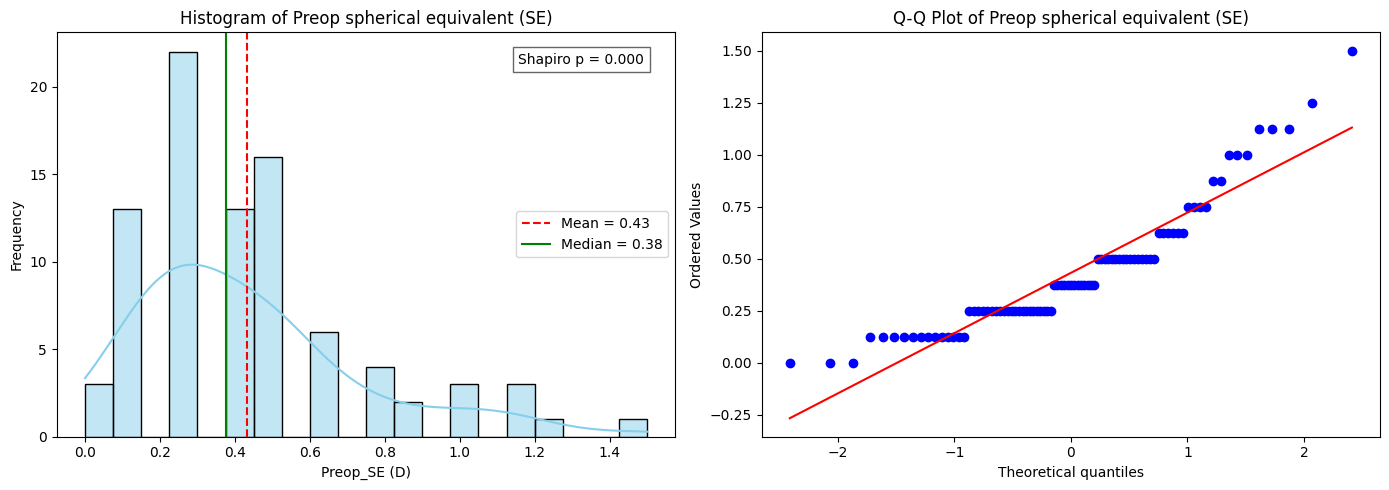

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# Compute Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(sorted_data['Preop_SE'])

# Compute mean and median
mean_val = sorted_data['Preop_SE'].mean()
median_val = sorted_data['Preop_SE'].median()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE
sns.histplot(sorted_data['Preop_SE'], bins=20, kde=True, color='skyblue', ax=axes[0], edgecolor='black')
axes[0].axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.2f}')
axes[0].axvline(median_val, color='green', linestyle='-', label=f'Median = {median_val:.2f}')
axes[0].set_title('Histogram of Preop spherical equivalent (SE)')
axes[0].set_xlabel('Preop_SE (D)')
axes[0].set_ylabel('Frequency')
axes[0].text(0.95, 0.95, f'Shapiro p = {shapiro_p:.3f}',
             transform=axes[0].transAxes, ha='right', va='top',
             bbox=dict(facecolor='white', alpha=0.6))
axes[0].legend()

# Q-Q plot
stats.probplot(sorted_data['Preop_SE'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot of Preop spherical equivalent (SE)')

plt.tight_layout()
plt.show()


In [18]:
import numpy as np

def classify_astigmatism(axis):
    if (axis >= 0 and axis <= 30) or (axis >= 150 and axis <= 180):
        return 'WTR'
    elif axis >= 60 and axis <= 120:
        return 'ATR'
    else:
        return 'Oblique'

# Apply classification
sorted_data['Preop_astig_type'] = sorted_data['PreopA1'].apply(classify_astigmatism)

# View counts
print(sorted_data['Preop_astig_type'].value_counts())


Preop_astig_type
ATR        40
WTR        32
Oblique    15
Name: count, dtype: int64


In [19]:
# Counts
counts = sorted_data['Preop_astig_type'].value_counts()
print("Counts:\n", counts)

# Proportions
proportions = sorted_data['Preop_astig_type'].value_counts(normalize=True) * 100
print("\nProportions (%):\n", proportions.round(2))


Counts:
 Preop_astig_type
ATR        40
WTR        32
Oblique    15
Name: count, dtype: int64

Proportions (%):
 Preop_astig_type
ATR        45.98
WTR        36.78
Oblique    17.24
Name: proportion, dtype: float64


In [20]:
import numpy as np

# Convert axis to radians
theta = np.deg2rad(sorted_data['PreopA1'])

# Calculate J0 and J45
sorted_data['Preop_J0'] = (-sorted_data['Preop_cyl'] / 2) * np.cos(2 * theta).round(2)
sorted_data['Preop_J45'] = (-sorted_data['Preop_cyl'] / 2) * np.sin(2 * theta).round(2)


In [21]:
import numpy as np

# Convert axis to radians
theta = np.deg2rad(sorted_data['PreopA1'])

# Calculate J0 and J45
sorted_data['Preop_J0'] = (-sorted_data['Preop_cyl'] / 2) * np.cos(2 * theta).round(2)
sorted_data['Preop_J45'] = (-sorted_data['Preop_cyl'] / 2) * np.sin(2 * theta).round(2)

def classify_vector_astig(J0, J45, threshold=0.75):
    if abs(J45) > abs(J0) * threshold:
        return 'Oblique'
    elif J0 < 0:
        return 'WTR'
    else:
        return 'ATR'

sorted_data['Preop_astig_type_vector'] = sorted_data.apply(
    lambda row: classify_vector_astig(row['Preop_J0'], row['Preop_J45']), axis=1
)

# Counts and proportions
counts = sorted_data['Preop_astig_type_vector'].value_counts()
proportions = sorted_data['Preop_astig_type_vector'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nProportions (%):\n", proportions.round(2))


Counts:
 Preop_astig_type_vector
ATR        34
Oblique    32
WTR        21
Name: count, dtype: int64

Proportions (%):
 Preop_astig_type_vector
ATR        39.08
Oblique    36.78
WTR        24.14
Name: proportion, dtype: float64


In [22]:
import pandas as pd

# Side-by-side comparison
comparison_table = pd.crosstab(
    sorted_data['Preop_astig_type'],          # Axis-based
    sorted_data['Preop_astig_type_vector'],  # Vector-based
    rownames=['Axis-based'],
    colnames=['Vector-based']
)

print(comparison_table)


Vector-based  ATR  Oblique  WTR
Axis-based                     
ATR            31        9    0
Oblique         0       15    0
WTR             3        8   21


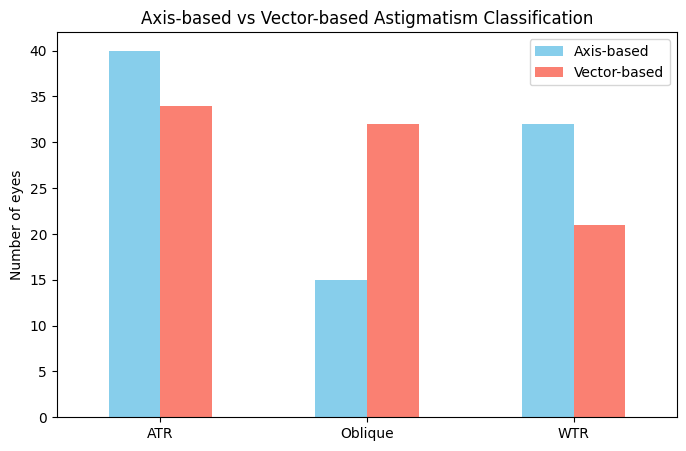

In [23]:
import matplotlib.pyplot as plt

# Counts for each method
axis_counts = sorted_data['Preop_astig_type'].value_counts().sort_index()
vector_counts = sorted_data['Preop_astig_type_vector'].value_counts().sort_index()

# Combine into DataFrame
counts_df = pd.DataFrame({
    'Axis-based': axis_counts,
    'Vector-based': vector_counts
}).fillna(0)

# Plot
counts_df.plot(kind='bar', figsize=(8,5), color=['skyblue','salmon'])
plt.ylabel('Number of eyes')
plt.title('Axis-based vs Vector-based Astigmatism Classification')
plt.xticks(rotation=0)
plt.show()


In [24]:
# Count of exact matches
agreement_count = (sorted_data['Preop_astig_type'] == sorted_data['Preop_astig_type_vector']).sum()

# Total number of eyes
total = len(sorted_data)

# Overall agreement (%)
overall_agreement = (agreement_count / total) * 100
print(f"Overall agreement: {overall_agreement:.2f}%")


Overall agreement: 77.01%


In [25]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(
    sorted_data['Preop_astig_type'],
    sorted_data['Preop_astig_type_vector']
)

print(f"Cohen's kappa: {kappa:.2f}")


Cohen's kappa: 0.66


In [26]:
sorted_data

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,...,Cyl3mth,Axis3mth,Preop_cyl,Preop_meanK,Preop_SE,Preop_steepaxis,Preop_astig_type,Preop_J0,Preop_J45,Preop_astig_type_vector
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,...,-1.00,65.0,0.75,46.875,0.375,65,WTR,-0.24000,0.28875,Oblique
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,...,-2.00,80.0,1.25,47.375,0.625,170,ATR,0.58750,-0.21250,ATR
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,...,-0.50,150.0,0.50,45.500,0.250,30,ATR,0.12500,0.21750,Oblique
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,...,-2.25,80.0,1.00,43.000,0.500,165,ATR,0.43500,-0.25000,ATR
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,...,-1.50,70.0,1.50,43.750,0.750,0,ATR,0.75000,-0.00000,ATR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,...,-3.25,120.0,0.75,47.125,0.375,100,WTR,-0.35250,-0.12750,WTR
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,...,0.50,110.0,2.00,45.750,1.000,145,Oblique,0.34000,-0.94000,Oblique
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,...,-3.00,90.0,0.75,43.625,0.375,150,ATR,0.18750,-0.32625,Oblique
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,...,-1.25,75.0,0.50,42.250,0.250,20,ATR,0.19250,0.16000,Oblique


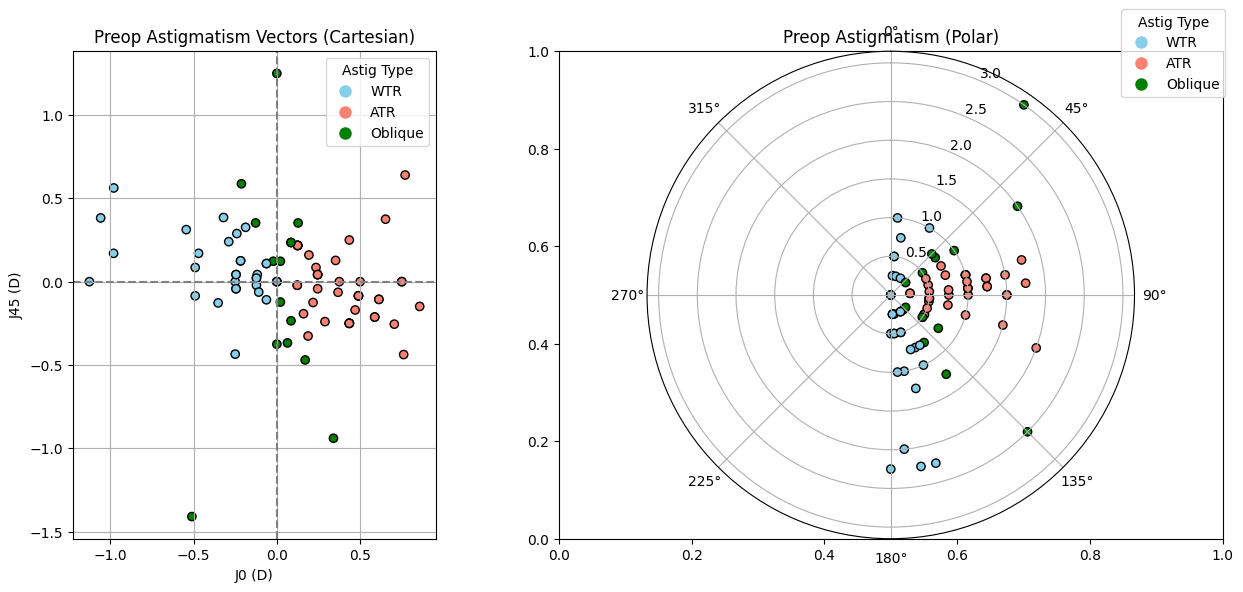

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Color mapping for astigmatism type
color_map = {'WTR':'skyblue', 'ATR':'salmon', 'Oblique':'green'}
colors = sorted_data['Preop_astig_type'].map(color_map)

# Compute polar coordinates
cylinder = sorted_data['Preop_cyl']
axis_rad = np.deg2rad(sorted_data['PreopA1'])

# Create side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Cartesian plot (J0 vs J45)
axes[0].scatter(sorted_data['Preop_J0'], sorted_data['Preop_J45'], c=colors, edgecolor='black')
axes[0].axhline(0, color='gray', linestyle='--')
axes[0].axvline(0, color='gray', linestyle='--')
axes[0].set_xlabel('J0 (D)')
axes[0].set_ylabel('J45 (D)')
axes[0].set_title('Preop Astigmatism Vectors (Cartesian)')
axes[0].grid(True)
axes[0].set_aspect('equal', adjustable='box')

# Polar plot (cylinder magnitude vs flat axis)
ax_polar = fig.add_subplot(1, 2, 2, polar=True)
scatter = ax_polar.scatter(axis_rad, cylinder, c=colors, edgecolor='black')
ax_polar.set_theta_zero_location("N")
ax_polar.set_theta_direction(-1)
ax_polar.set_title('Preop Astigmatism (Polar)')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=key,
                          markerfacecolor=color_map[key], markersize=10) for key in color_map]
axes[0].legend(handles=legend_elements, title='Astig Type', loc='upper right')
ax_polar.legend(handles=legend_elements, title='Astig Type', loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
plt.show()

In this cohort, preoperative corneal astigmatism was predominantly ATR and WTR by axis-based classification, with a smaller proportion of Oblique astigmatism. Vector-based analysis using J0 and J45 confirmed these findings and revealed additional eyes with subtle oblique components that were not captured by conventional axis-based thresholds. The overall agreement between axis- and vector-based classifications was 77%, with a Cohen’s kappa of 0.66, indicating substantial concordance.
Cartesian plots of J0 versus J45 provided a clear visualization of the distribution of astigmatism vectors, highlighting the relative contributions of WTR, ATR, and oblique components. Polar plots of cylinder magnitude versus flat meridian axis further demonstrated the orientation and magnitude of astigmatism across the cohort, facilitating a comprehensive understanding of preoperative corneal characteristics.
These combined analytical approaches underscore the importance of incorporating vector-based metrics alongside traditional axis-based classifications for accurate characterization of corneal astigmatism. Such detailed assessment is critical for surgical planning, toric intraocular lens selection, and optimizing refractive outcomes. Future studies could explore longitudinal changes in vector components postoperatively to better predict refractive stability and visual outcomes.

In [28]:
sorted_data

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,...,Cyl3mth,Axis3mth,Preop_cyl,Preop_meanK,Preop_SE,Preop_steepaxis,Preop_astig_type,Preop_J0,Preop_J45,Preop_astig_type_vector
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,...,-1.00,65.0,0.75,46.875,0.375,65,WTR,-0.24000,0.28875,Oblique
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,...,-2.00,80.0,1.25,47.375,0.625,170,ATR,0.58750,-0.21250,ATR
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,...,-0.50,150.0,0.50,45.500,0.250,30,ATR,0.12500,0.21750,Oblique
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,...,-2.25,80.0,1.00,43.000,0.500,165,ATR,0.43500,-0.25000,ATR
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,...,-1.50,70.0,1.50,43.750,0.750,0,ATR,0.75000,-0.00000,ATR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,...,-3.25,120.0,0.75,47.125,0.375,100,WTR,-0.35250,-0.12750,WTR
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,...,0.50,110.0,2.00,45.750,1.000,145,Oblique,0.34000,-0.94000,Oblique
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,...,-3.00,90.0,0.75,43.625,0.375,150,ATR,0.18750,-0.32625,Oblique
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,...,-1.25,75.0,0.50,42.250,0.250,20,ATR,0.19250,0.16000,Oblique


In [29]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cyl', 'Preop_meanK', 'Preop_SE', 'Preop_steepaxis',
       'Preop_astig_type', 'Preop_J0', 'Preop_J45', 'Preop_astig_type_vector'],
      dtype='object')

In [30]:
import numpy as np

# Convert axis to radians
theta = np.deg2rad(sorted_data['Axis1wk'])

# Calculate J0 and J45
sorted_data['SE_1wk'] = sorted_data['Sph1wk']+ (sorted_data['Cyl1wk']/2)
sorted_data['J0_1wk'] = (-sorted_data['Cyl1wk'] / 2) * np.cos(2 * theta).round(2)
sorted_data['J45_1wk'] = (-sorted_data['Cyl1wk'] / 2) * np.sin(2 * theta).round(2)


In [31]:
sorted_data

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,...,Preop_meanK,Preop_SE,Preop_steepaxis,Preop_astig_type,Preop_J0,Preop_J45,Preop_astig_type_vector,SE_1wk,J0_1wk,J45_1wk
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,...,46.875,0.375,65,WTR,-0.24000,0.28875,Oblique,-0.5,-0.4800,-0.57750
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,...,47.375,0.625,170,ATR,0.58750,-0.21250,ATR,-0.375,-1.0575,0.38250
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,...,45.500,0.250,30,ATR,0.12500,0.21750,Oblique,-1.25,0.3850,-0.32000
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,...,43.000,0.500,165,ATR,0.43500,-0.25000,ATR,1.0,-1.0000,0.00000
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,...,43.750,0.750,0,ATR,0.75000,-0.00000,ATR,-1.25,-0.2350,-0.08500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,...,47.125,0.375,100,WTR,-0.35250,-0.12750,WTR,-4.0,-1.3475,1.12000
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,...,45.750,1.000,145,Oblique,0.34000,-0.94000,Oblique,1.25,0.0850,-0.49000
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,...,43.625,0.375,150,ATR,0.18750,-0.32625,Oblique,-4.25,-0.7500,1.30500
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,...,42.250,0.250,20,ATR,0.19250,0.16000,Oblique,-1.375,-0.6125,-0.10625


In [32]:
import numpy as np

# Convert axis to radians
theta = np.deg2rad(sorted_data['Axis6wk'])

# Calculate J0 and J45
sorted_data['SE_6wk'] = sorted_data['Sph6wk']+ (sorted_data['Cyl6wk']/2)
sorted_data['J0_6wk'] = (-sorted_data['Cyl6wk'] / 2) * np.cos(2 * theta).round(2)
sorted_data['J45_6wk'] = (-sorted_data['Cyl6wk'] / 2) * np.sin(2 * theta).round(2)


In [33]:
import numpy as np

# Convert axis to radians
theta = np.deg2rad(sorted_data['Axis3mth'])

# Calculate J0 and J45
sorted_data['SE_3mth'] = sorted_data['Sph3mth']+ (sorted_data['Cyl3mth']/2)
sorted_data['J0_3mth'] = (-sorted_data['Cyl3mth'] / 2) * np.cos(2 * theta).round(2)
sorted_data['J45_3mth'] = (-sorted_data['Cyl3mth'] / 2) * np.sin(2 * theta).round(2)


In [34]:
# Define a function to classify SE
def classify_se(se):
    if se > 0:
        return 'Hyperopic'
    elif se < 0:
        return 'Myopic'
    else:
        return 'Emmetropic'

# Apply the function to each follow-up column
sorted_data['SE_1wk_class'] = sorted_data['SE_1wk'].apply(classify_se)
sorted_data['SE_6wk_class'] = sorted_data['SE_6wk'].apply(classify_se)
sorted_data['SE_3mth_class'] = sorted_data['SE_3mth'].apply(classify_se)


In [35]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cyl', 'Preop_meanK', 'Preop_SE', 'Preop_steepaxis',
       'Preop_astig_type', 'Preop_J0', 'Preop_J45', 'Preop_astig_type_vector',
       'SE_1wk', 'J0_1wk', 'J45_1wk', 'SE_6wk', 'J0_6wk', 'J45_6wk', 'SE_3mth',
       'J0_3mth', 'J45_3mth', 'SE_1wk_class', 'SE_6wk_class', 'SE_3mth_class'],
      dtype='object')

In [36]:
sorted_data

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,...,J45_1wk,SE_6wk,J0_6wk,J45_6wk,SE_3mth,J0_3mth,J45_3mth,SE_1wk_class,SE_6wk_class,SE_3mth_class
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,...,-0.57750,-0.375,-0.58750,-0.2125,0.000,-0.32000,0.38500,Myopic,Myopic,Emmetropic
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,...,0.38250,-0.25,-1.00000,0.0000,-0.500,-0.94000,0.34000,Myopic,Myopic,Myopic
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,...,-0.32000,-0.875,0.06375,-0.3675,-0.750,0.12500,-0.21750,Myopic,Myopic,Myopic
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,...,0.00000,0.75,-0.94000,0.3400,0.625,-1.05750,0.38250,Hyperopic,Hyperopic,Hyperopic
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,...,-0.08500,-1.625,-1.05750,0.3825,-1.250,-0.57750,0.48000,Myopic,Myopic,Myopic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,...,1.12000,-3.625,-1.62500,0.0000,-3.875,-0.81250,-1.41375,Myopic,Myopic,Myopic
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,...,-0.49000,0.75,0.21750,-0.1250,0.500,0.19250,0.16000,Hyperopic,Hyperopic,Hyperopic
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,...,1.30500,-4.0,-1.47000,-0.2550,-3.500,-1.50000,0.00000,Myopic,Myopic,Myopic
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,...,-0.10625,-1.0,-0.25000,0.4350,-1.125,-0.54375,0.31250,Myopic,Myopic,Myopic


In [37]:
import pandas as pd

# Columns with classifications
se_columns = ['SE_1wk_class', 'SE_6wk_class', 'SE_3mth_class']
visits = ['1wk', '6wk', '3mth']

# Initialize empty DataFrame for summary
summary = pd.DataFrame()

for col, visit in zip(se_columns, visits):
    counts = sorted_data[col].value_counts()
    props = sorted_data[col].value_counts(normalize=True) * 100

    # Combine counts and percentages
    combined = counts.astype(str) + ' (' + props.round(1).astype(str) + '%)'
    combined.name = visit
    summary = pd.concat([summary, combined], axis=1)

# Fill missing values with '0 (0%)' if a category is absent
summary = summary.fillna('0 (0%)')

# Reorder index for clarity
summary = summary.reindex(['Hyperopic', 'Myopic', 'Emmetropic'])

print(summary)


                   1wk         6wk        3mth
Hyperopic   28 (32.2%)  26 (29.9%)  28 (32.2%)
Myopic      58 (66.7%)  57 (65.5%)  55 (63.2%)
Emmetropic    1 (1.1%)    4 (4.6%)    4 (4.6%)


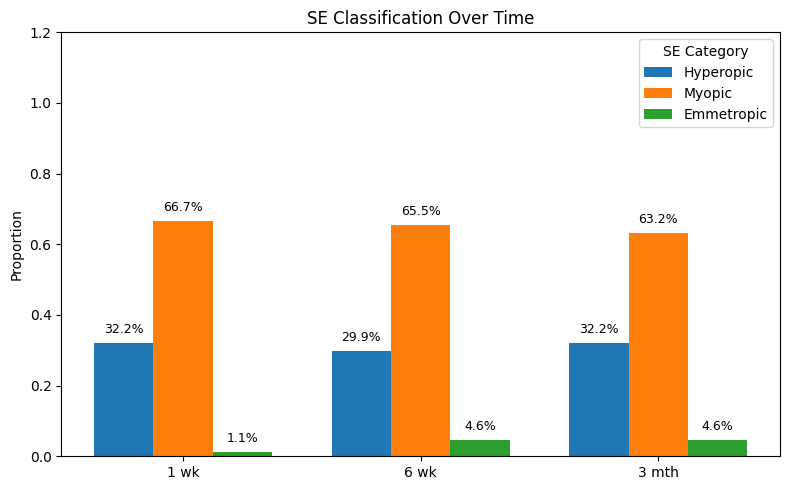

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Columns with classification
se_columns = ['SE_1wk_class', 'SE_6wk_class', 'SE_3mth_class']
visits = ['1 wk', '6 wk', '3 mth']

# Calculate proportions
proportions = pd.DataFrame({visit: sorted_data[col].value_counts(normalize=True)
                            for col, visit in zip(se_columns, visits)}).fillna(0)

# Reorder rows
proportions = proportions.reindex(['Hyperopic', 'Myopic', 'Emmetropic'])

# Plotting
categories = proportions.index
n_categories = len(categories)
x = np.arange(len(visits))  # label locations
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(8,5))

for i, cat in enumerate(categories):
    bars = ax.bar(x + i*width - width, proportions.loc[cat], width, label=cat)
    # Add percentage labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height*100:.1f}%',
                ha='center', va='bottom', fontsize=9)

# Labels and title
ax.set_ylabel('Proportion')
ax.set_title('SE Classification Over Time')
ax.set_xticks(x)
ax.set_xticklabels(visits)
ax.set_ylim(0, 1.2)  # extra space for labels
ax.legend(title='SE Category')
plt.tight_layout()
plt.show()


In [39]:
import numpy as np

def calculate_J0_J45(cyl, axis):
    axis_rad = np.deg2rad(2 * axis)
    J0 = -cyl / 2 * np.cos(axis_rad).round(2)
    J45 = -cyl / 2 * np.sin(axis_rad).round(2)
    return J0, J45


In [40]:
sorted_data['J0_1wk'], sorted_data['J45_1wk'] = calculate_J0_J45(
    sorted_data['Cyl1wk'],
    sorted_data['Axis1wk']
)

sorted_data['J0_6wk'], sorted_data['J45_6wk'] = calculate_J0_J45(
    sorted_data['Cyl6wk'],
    sorted_data['Axis6wk']
)

sorted_data['J0_3mth'], sorted_data['J45_3mth'] = calculate_J0_J45(
    sorted_data['Cyl3mth'],
    sorted_data['Axis3mth']
)


In [41]:
sorted_data

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,...,J45_1wk,SE_6wk,J0_6wk,J45_6wk,SE_3mth,J0_3mth,J45_3mth,SE_1wk_class,SE_6wk_class,SE_3mth_class
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,...,-0.57750,-0.375,-0.58750,-0.2125,0.000,-0.32000,0.38500,Myopic,Myopic,Emmetropic
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,...,0.38250,-0.25,-1.00000,0.0000,-0.500,-0.94000,0.34000,Myopic,Myopic,Myopic
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,...,-0.32000,-0.875,0.06375,-0.3675,-0.750,0.12500,-0.21750,Myopic,Myopic,Myopic
5,59,F,42.50,43.50,75,2,-2.00,90.0,1.75,-2.00,...,0.00000,0.75,-0.94000,0.3400,0.625,-1.05750,0.38250,Hyperopic,Hyperopic,Hyperopic
7,63,F,43.00,44.50,90,-1,-0.50,100.0,-0.5,-2.25,...,-0.08500,-1.625,-1.05750,0.3825,-1.250,-0.57750,0.48000,Myopic,Myopic,Myopic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,59,F,46.75,47.50,10,-2.25,-3.50,70.0,-2,-3.25,...,1.12000,-3.625,-1.62500,0.0000,-3.875,-0.81250,-1.41375,Myopic,Myopic,Myopic
162,69,F,44.75,46.75,55,0.75,1.00,50.0,0.5,0.50,...,-0.49000,0.75,0.21750,-0.1250,0.500,0.19250,0.16000,Hyperopic,Hyperopic,Hyperopic
163,66,F,43.25,44.00,60,-2.75,-3.00,60.0,-2.5,-3.00,...,1.30500,-4.0,-1.47000,-0.2550,-3.500,-1.50000,0.00000,Myopic,Myopic,Myopic
166,52,F,42.00,42.50,110,-0.75,-1.25,95.0,-0.5,-1.00,...,-0.10625,-1.0,-0.25000,0.4350,-1.125,-0.54375,0.31250,Myopic,Myopic,Myopic


In [42]:
# Calculate mean vectors
mean_vectors = {
    'Preop': (sorted_data['Preop_J0'].mean(), sorted_data['Preop_J45'].mean()),
    '1 wk': (sorted_data['J0_1wk'].mean(), sorted_data['J45_1wk'].mean()),
    '6 wk': (sorted_data['J0_6wk'].mean(), sorted_data['J45_6wk'].mean()),
    '3 mth': (sorted_data['J0_3mth'].mean(), sorted_data['J45_3mth'].mean())
}


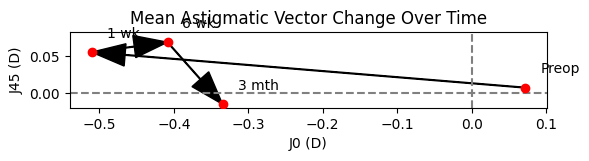

In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

# Extract values
labels = list(mean_vectors.keys())
J0_vals = [mean_vectors[k][0] for k in labels]
J45_vals = [mean_vectors[k][1] for k in labels]

# Plot arrows
for i in range(len(labels)-1):
    ax.arrow(
        J0_vals[i], J45_vals[i],
        J0_vals[i+1] - J0_vals[i],
        J45_vals[i+1] - J45_vals[i],
        head_width=0.03, length_includes_head=True,
        color='black'
    )

# Plot points
ax.scatter(J0_vals, J45_vals, color='red', zorder=3)

# Annotate points
for i, label in enumerate(labels):
    ax.text(J0_vals[i]+0.02, J45_vals[i]+0.02, label)

# Axes formatting
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title('Mean Astigmatic Vector Change Over Time')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


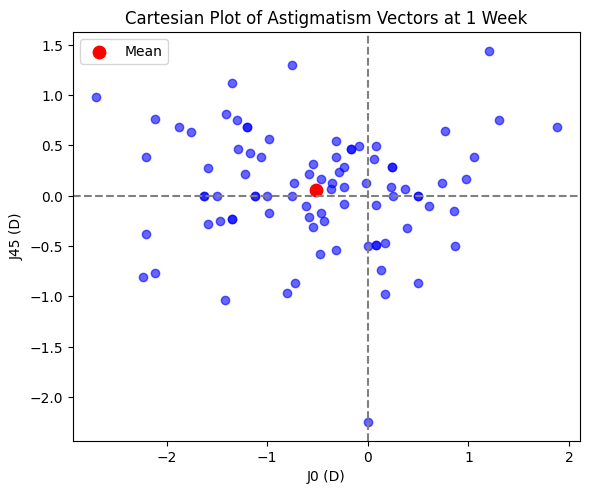

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,6))

# Scatter plot of individual eyes
ax.scatter(
    sorted_data['J0_1wk'],
    sorted_data['J45_1wk'],
    alpha=0.6,
    color='blue'
)

# Plot mean vector
mean_J0 = sorted_data['J0_1wk'].mean()
mean_J45 = sorted_data['J45_1wk'].mean()

ax.scatter(mean_J0, mean_J45, color='red', s=80, label='Mean')

# Reference axes
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')

# Formatting
ax.set_xlabel('J0 (D)')
ax.set_ylabel('J45 (D)')
ax.set_title('Cartesian Plot of Astigmatism Vectors at 1 Week')
ax.set_aspect('equal', adjustable='box')
ax.legend()

plt.tight_layout()
plt.show()


In [46]:
import numpy as np
import matplotlib.pyplot as plt

time_points = ['Preop', '1 wk', '6 wk', '3 mth']

# Column mapping
cols = {
    'Preop': ('Preop_J0', 'Preop_J45'),
    '1 wk': ('J0_1wk', 'J45_1wk'),
    '6 wk': ('J0_6wk', 'J45_6wk'),
    '3 mth': ('J0_3mth', 'J45_3mth')
}

# Means
mean_J0 = [sorted_data[cols[t][0]].mean() for t in time_points]
mean_J45 = [sorted_data[cols[t][1]].mean() for t in time_points]

# SD
sd_J0 = [sorted_data[cols[t][0]].std() for t in time_points]
sd_J45 = [sorted_data[cols[t][1]].std() for t in time_points]

# Sample sizes (for SEM)
n = [sorted_data[cols[t][0]].count() for t in time_points]

# SEM (use this instead of SD if desired)
sem_J0 = [sd / np.sqrt(n[i]) for i, sd in enumerate(sd_J0)]
sem_J45 = [sd / np.sqrt(n[i]) for i, sd in enumerate(sd_J45)]


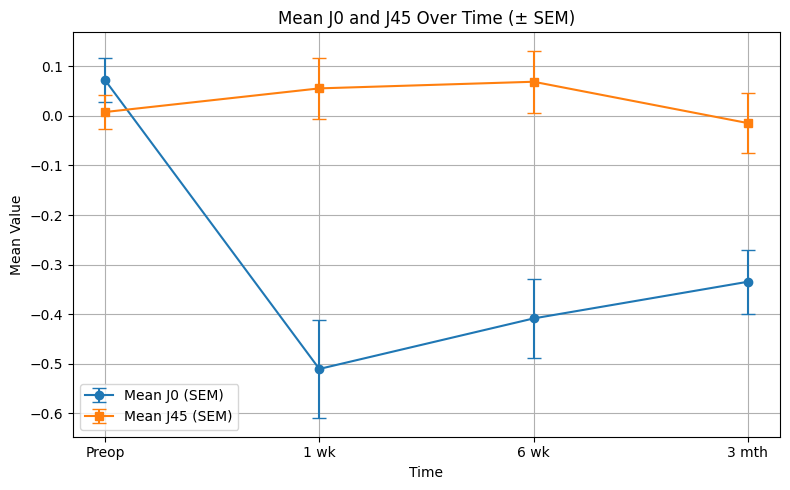

In [47]:
plt.figure(figsize=(8, 5))

plt.errorbar(time_points, mean_J0, yerr=sem_J0,
             marker='o', capsize=5, label='Mean J0 (SEM)')

plt.errorbar(time_points, mean_J45, yerr=sem_J45,
             marker='s', capsize=5, label='Mean J45 (SEM)')

plt.xlabel('Time')
plt.ylabel('Mean Value')
plt.title('Mean J0 and J45 Over Time (± SEM)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [48]:
sorted_data.columns

Index(['Age', 'Gender', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'Preop_cyl', 'Preop_meanK', 'Preop_SE', 'Preop_steepaxis',
       'Preop_astig_type', 'Preop_J0', 'Preop_J45', 'Preop_astig_type_vector',
       'SE_1wk', 'J0_1wk', 'J45_1wk', 'SE_6wk', 'J0_6wk', 'J45_6wk', 'SE_3mth',
       'J0_3mth', 'J45_3mth', 'SE_1wk_class', 'SE_6wk_class', 'SE_3mth_class'],
      dtype='object')

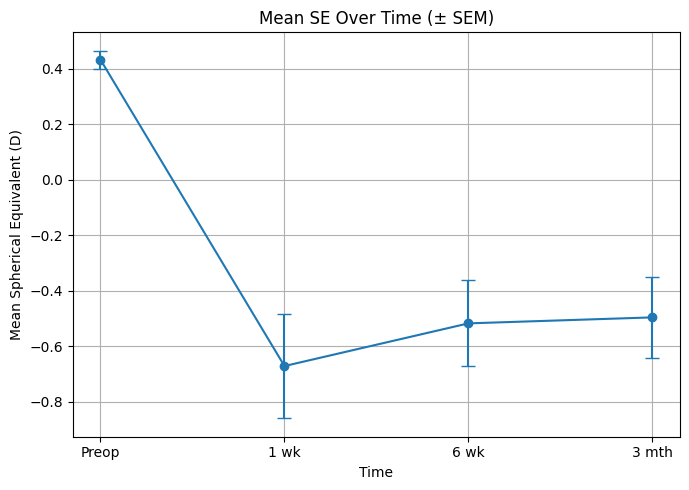

In [53]:
import numpy as np
import matplotlib.pyplot as plt

time_points = ['Preop', '1 wk', '6 wk', '3 mth']
se_cols = ['Preop_SE', 'SE_1wk', 'SE_6wk', 'SE_3mth']

mean_SE = [sorted_data[col].mean() for col in se_cols]
# Standard deviation
sd_SE = [sorted_data[col].std() for col in se_cols]

# Sample size
n = [sorted_data[col].count() for col in se_cols]

# Standard error of the mean
sem_SE = [sd_SE[i] / np.sqrt(n[i]) for i in range(len(sd_SE))]



plt.figure(figsize=(7, 5))

plt.errorbar(time_points, mean_SE, yerr=sem_SE,
             marker='o', capsize=5)

plt.xlabel('Time')
plt.ylabel('Mean Spherical Equivalent (D)')
plt.title('Mean SE Over Time (± SEM)')
plt.grid(True)

plt.tight_layout()
plt.show()


In [54]:
import numpy as np
import matplotlib.pyplot as plt

time_points = ['Preop', '1 wk', '6 wk', '3 mth']

# Columns
j0_cols = ['Preop_J0', 'J0_1wk', 'J0_6wk', 'J0_3mth']
j45_cols = ['Preop_J45', 'J45_1wk', 'J45_6wk', 'J45_3mth']
se_cols = ['Preop_SE', 'SE_1wk', 'SE_6wk', 'SE_3mth']

# Means
mean_J0 = [sorted_data[col].mean() for col in j0_cols]
mean_J45 = [sorted_data[col].mean() for col in j45_cols]
mean_SE = [sorted_data[col].mean() for col in se_cols]

# SEM (recommended)
sem_J0 = [sorted_data[col].std() / np.sqrt(sorted_data[col].count()) for col in j0_cols]
sem_J45 = [sorted_data[col].std() / np.sqrt(sorted_data[col].count()) for col in j45_cols]
sem_SE = [sorted_data[col].std() / np.sqrt(sorted_data[col].count()) for col in se_cols]


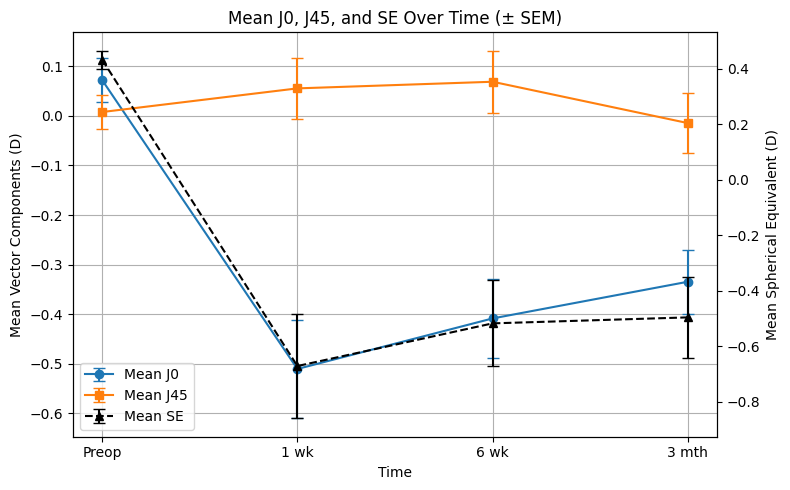

In [55]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Left Y-axis: J0 and J45
ax1.errorbar(time_points, mean_J0, yerr=sem_J0,
             marker='o', capsize=4, label='Mean J0')
ax1.errorbar(time_points, mean_J45, yerr=sem_J45,
             marker='s', capsize=4, label='Mean J45')

ax1.set_xlabel('Time')
ax1.set_ylabel('Mean Vector Components (D)')
ax1.grid(True)

# Right Y-axis: SE
ax2 = ax1.twinx()
ax2.errorbar(time_points, mean_SE, yerr=sem_SE,
             marker='^', linestyle='--', capsize=4,
             color='black', label='Mean SE')

ax2.set_ylabel('Mean Spherical Equivalent (D)')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title('Mean J0, J45, and SE Over Time (± SEM)')
plt.tight_layout()
plt.show()


In [56]:
import matplotlib.pyplot as plt

time_points = ['Preop', '1 wk', '6 wk', '3 mth']

j0_cols = ['Preop_J0', 'J0_1wk', 'J0_6wk', 'J0_3mth']
j45_cols = ['Preop_J45', 'J45_1wk', 'J45_6wk', 'J45_3mth']

mean_J0 = [sorted_data[col].mean() for col in j0_cols]
mean_J45 = [sorted_data[col].mean() for col in j45_cols]


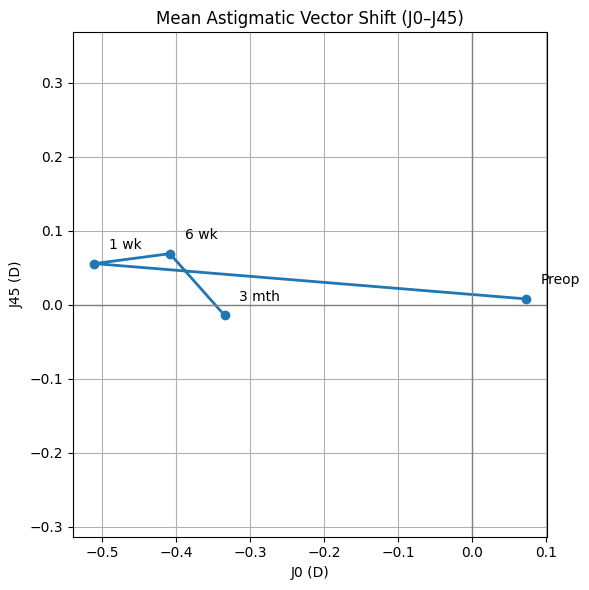

In [57]:
plt.figure(figsize=(6, 6))

# Plot trajectory
plt.plot(mean_J0, mean_J45, marker='o', linewidth=2)

# Label each time point
for i, label in enumerate(time_points):
    plt.text(mean_J0[i] + 0.02, mean_J45[i] + 0.02, label)

# Axes lines through origin
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.xlabel('J0 (D)')
plt.ylabel('J45 (D)')
plt.title('Mean Astigmatic Vector Shift (J0–J45)')

plt.axis('equal')
plt.grid(True)

plt.tight_layout()
plt.show()


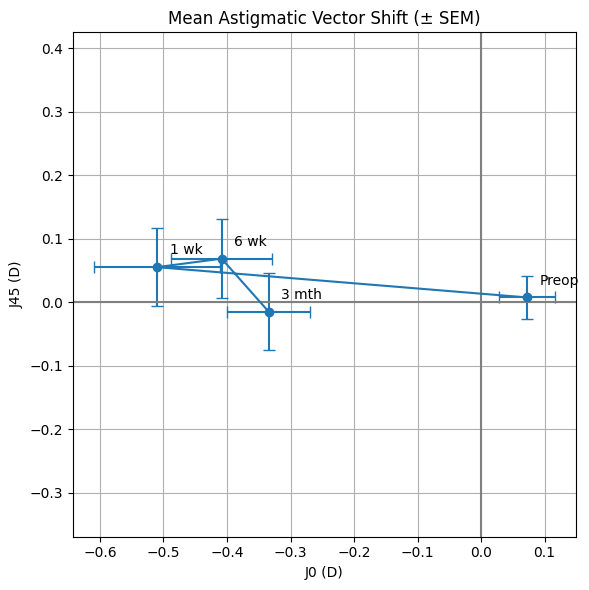

In [58]:
import numpy as np

sem_J0 = [sorted_data[col].std() / np.sqrt(sorted_data[col].count()) for col in j0_cols]
sem_J45 = [sorted_data[col].std() / np.sqrt(sorted_data[col].count()) for col in j45_cols]

plt.figure(figsize=(6, 6))

plt.errorbar(mean_J0, mean_J45,
             xerr=sem_J0, yerr=sem_J45,
             fmt='o-', capsize=4)

for i, label in enumerate(time_points):
    plt.text(mean_J0[i] + 0.02, mean_J45[i] + 0.02, label)

plt.axhline(0, color='gray')
plt.axvline(0, color='gray')

plt.xlabel('J0 (D)')
plt.ylabel('J45 (D)')
plt.title('Mean Astigmatic Vector Shift (± SEM)')

plt.axis('equal')
plt.grid(True)
plt.tight_layout()
plt.show()


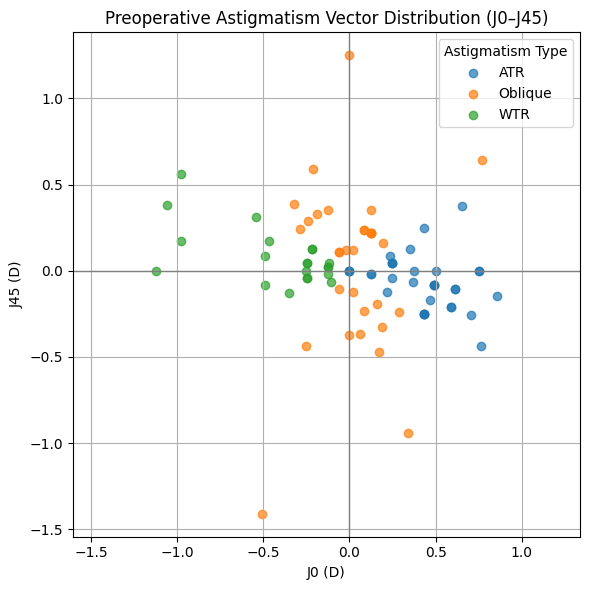

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Plot each astigmatic type separately
for astig_type, group in sorted_data.groupby('Preop_astig_type_vector'):
    plt.scatter(group['Preop_J0'],
                group['Preop_J45'],
                label=astig_type,
                alpha=0.7)

# Axes through origin
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.xlabel('J0 (D)')
plt.ylabel('J45 (D)')
plt.title('Preoperative Astigmatism Vector Distribution (J0–J45)')

plt.axis('equal')
plt.grid(True)
plt.legend(title='Astigmatism Type')

plt.tight_layout()
plt.show()


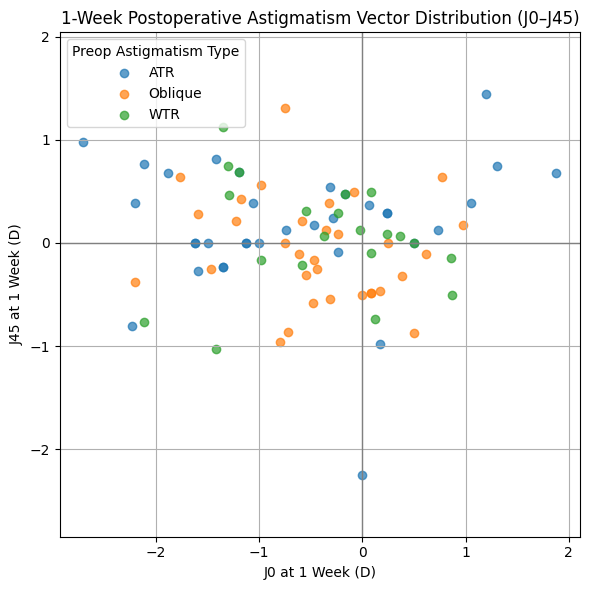

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Scatter by preop astigmatic vector type
for astig_type, group in sorted_data.groupby('Preop_astig_type_vector'):
    plt.scatter(group['J0_1wk'],
                group['J45_1wk'],
                label=astig_type,
                alpha=0.7)

# Axes through origin
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.xlabel('J0 at 1 Week (D)')
plt.ylabel('J45 at 1 Week (D)')
plt.title('1-Week Postoperative Astigmatism Vector Distribution (J0–J45)')

plt.axis('equal')
plt.grid(True)
plt.legend(title='Preop Astigmatism Type')

plt.tight_layout()
plt.show()


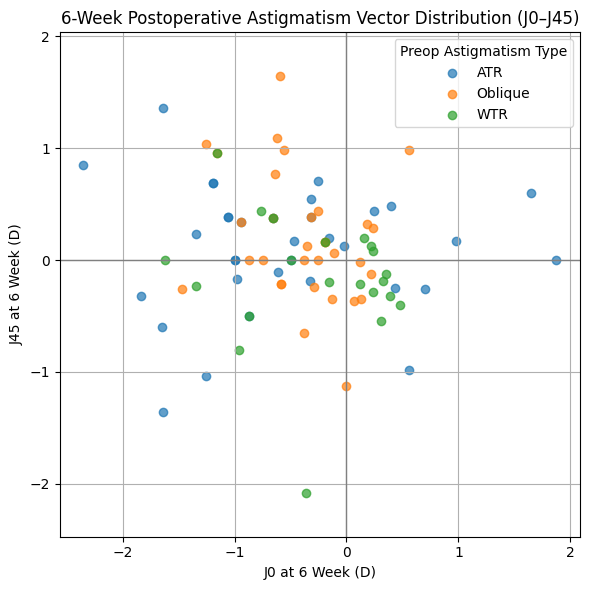

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Scatter by preop astigmatic vector type
for astig_type, group in sorted_data.groupby('Preop_astig_type_vector'):
    plt.scatter(group['J0_6wk'],
                group['J45_6wk'],
                label=astig_type,
                alpha=0.7)

# Axes through origin
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.xlabel('J0 at 6 Week (D)')
plt.ylabel('J45 at 6 Week (D)')
plt.title('6-Week Postoperative Astigmatism Vector Distribution (J0–J45)')

plt.axis('equal')
plt.grid(True)
plt.legend(title='Preop Astigmatism Type')

plt.tight_layout()
plt.show()


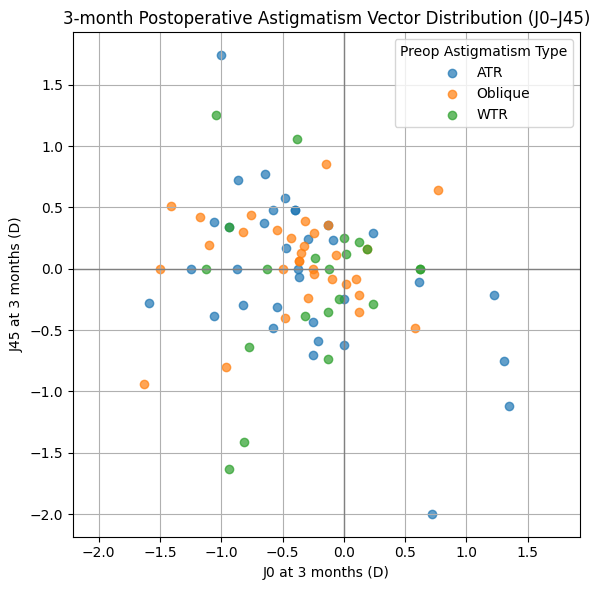

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

# Scatter by preop astigmatic vector type
for astig_type, group in sorted_data.groupby('Preop_astig_type_vector'):
    plt.scatter(group['J0_3mth'],
                group['J45_3mth'],
                label=astig_type,
                alpha=0.7)

# Axes through origin
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.xlabel('J0 at 3 months (D)')
plt.ylabel('J45 at 3 months (D)')
plt.title('3-month Postoperative Astigmatism Vector Distribution (J0–J45)')

plt.axis('equal')
plt.grid(True)
plt.legend(title='Preop Astigmatism Type')

plt.tight_layout()
plt.show()


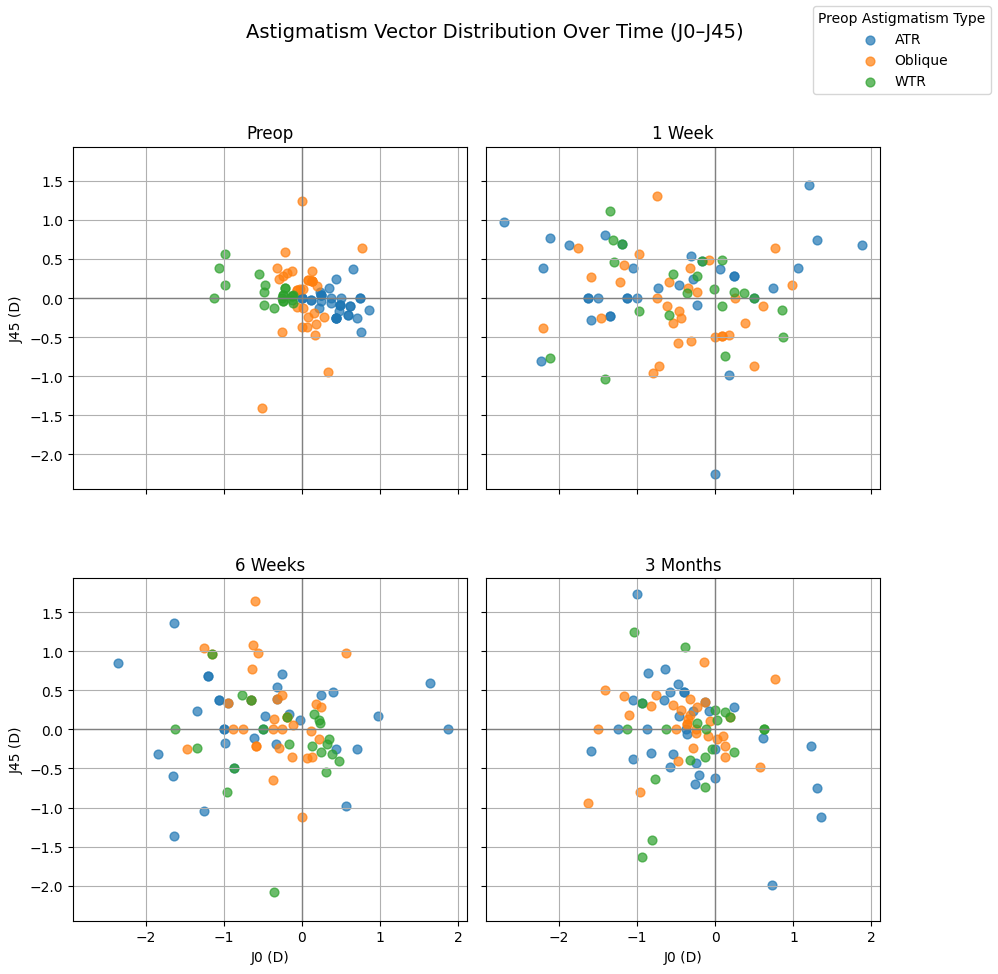

In [66]:
import matplotlib.pyplot as plt

# Time points and columns
panels = [
    ('Preop', 'Preop_J0', 'Preop_J45'),
    ('1 Week', 'J0_1wk', 'J45_1wk'),
    ('6 Weeks', 'J0_6wk', 'J45_6wk'),
    ('3 Months', 'J0_3mth', 'J45_3mth')
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, (title, j0_col, j45_col) in zip(axes, panels):
    for astig_type, group in sorted_data.groupby('Preop_astig_type_vector'):
        ax.scatter(group[j0_col],
                   group[j45_col],
                   label=astig_type,
                   alpha=0.7,
                   s=40)

    # Axes through origin
    ax.axhline(0, color='gray', linewidth=1)
    ax.axvline(0, color='gray', linewidth=1)

    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True)

# Axis labels (only outer)
axes[2].set_xlabel('J0 (D)')
axes[3].set_xlabel('J0 (D)')
axes[0].set_ylabel('J45 (D)')
axes[2].set_ylabel('J45 (D)')

# Unified legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           title='Preop Astigmatism Type',
           loc='upper right')

plt.suptitle('Astigmatism Vector Distribution Over Time (J0–J45)', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()


In [67]:
import numpy as np

def j0j45_to_polar(j0, j45):
    magnitude = 2 * np.sqrt(j0**2 + j45**2)
    axis_rad = 0.5 * np.arctan2(j45, j0)
    return magnitude, axis_rad


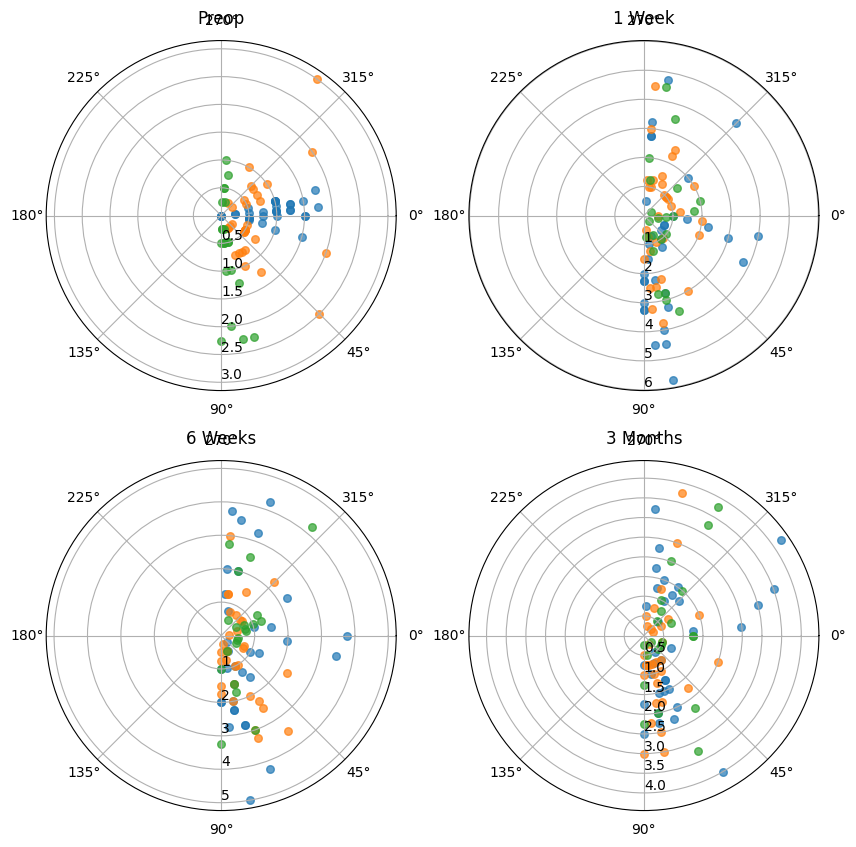

In [68]:
import matplotlib.pyplot as plt

panels = [
    ('Preop', 'Preop_J0', 'Preop_J45'),
    ('1 Week', 'J0_1wk', 'J45_1wk'),
    ('6 Weeks', 'J0_6wk', 'J45_6wk'),
    ('3 Months', 'J0_3mth', 'J45_3mth')
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10),
                         subplot_kw={'projection': 'polar'})
axes = axes.flatten()

for ax, (title, j0_col, j45_col) in zip(axes, panels):
    for astig_type, group in sorted_data.groupby('Preop_astig_type_vector'):
        mag, ang = j0j45_to_polar(group[j0_col], group[j45_col])

        ax.scatter(ang, mag,
                   label=astig_type,
                   alpha=0.7,
                   s=30)

    ax.set_title(title, pad=12)
    ax.set_theta_zero_location('E')   # 0° at horizontal
    ax.set_theta_direction(-1)        # clockwise
    ax.set_rlabel_position(90)
    ax.grid(True)
